# 01 - EDA & Data Quality Audit
## Digital Banking Customer Churn Prediction

Dataset: "Churn Modelling" bank customer churn dataset (10,000 rows), the same
dataset referenced in the Kaggle notebook
https://www.kaggle.com/code/kdsharma/banking-churn-analysis-modeling.
A local copy is stored at `data/raw/Churn_Modelling.csv` so this notebook
runs without Kaggle credentials.

Target: `Exited` (1 = customer churned, 0 = customer stayed).


In [1]:
# Add the src/ folder to the path so we can import our own churn_predictor package
import sys
sys.path.insert(0, "../src")

import pandas as pd
from churn_predictor.data import load_raw_data, quality_report

# Load the raw dataset and take a first look at the rows
df = load_raw_data()
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Shape, types, and quality checks

In [2]:
# Check the shape (rows, columns) and the data type of each column
import json

print(df.shape)
print(df.dtypes)

# Run our reusable data-quality audit: duplicates, missing values, target balance
print(json.dumps(quality_report(df), indent=2))

(10000, 14)
RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object
{
  "n_rows": 10000,
  "n_cols": 14,
  "n_duplicate_rows": 0,
  "n_duplicate_customer_ids": 0,
  "missing_by_column": {},
  "target_balance": {
    "0": 0.7963,
    "1": 0.2037
  }
}


**Findings:** 10,000 rows, 14 columns, no missing values, no duplicate rows,
no duplicate `CustomerId` values. The target is imbalanced (~80% stayed,
~20% exited) -- this is why the model comparison in notebook/experiments
uses recall/F1/ROC-AUC rather than plain accuracy, and why a Dummy baseline
is included for comparison.

## Target distribution

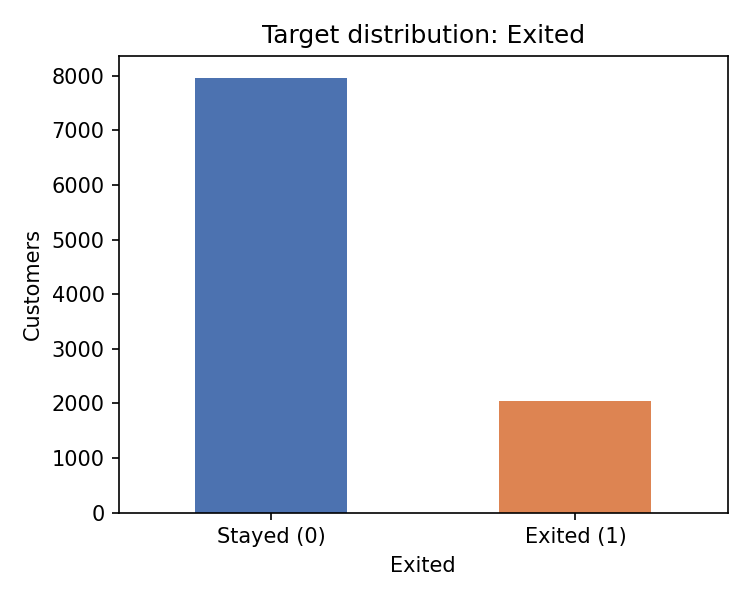

In [3]:
# Display the pre-generated target distribution chart (Exited vs stayed)
from IPython.display import Image

Image(filename="../reports/figures/target_distribution.png")

## Churn rate by Geography and Gender

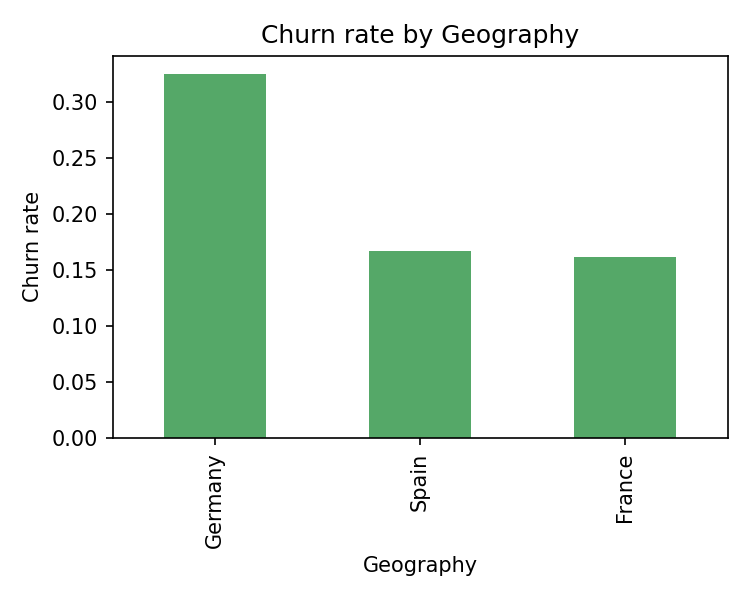

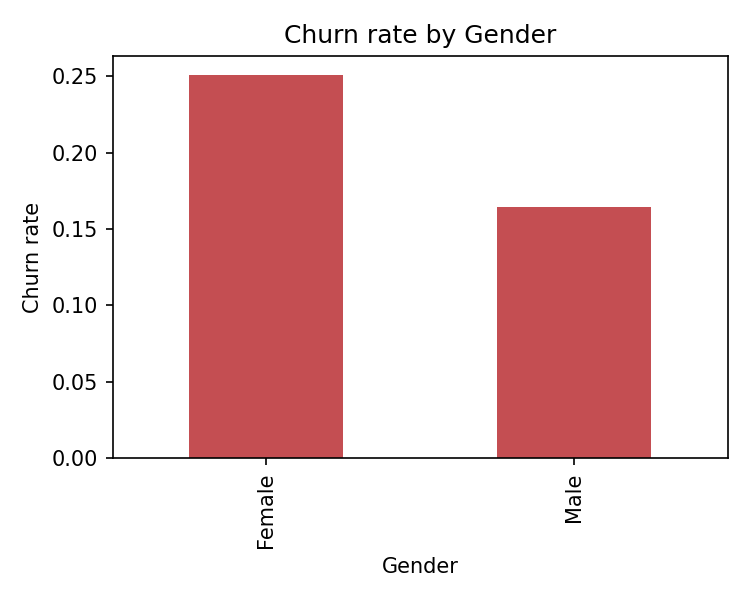

Geography
France     0.162
Germany    0.324
Spain      0.167
Name: Exited, dtype: float64
Gender
Female    0.251
Male      0.165
Name: Exited, dtype: float64


In [4]:
# Show churn rate broken down by Geography and by Gender, chart + exact numbers
display(Image(filename="../reports/figures/churn_by_geography.png"))
display(Image(filename="../reports/figures/churn_by_gender.png"))

# Print the precise churn rate per group so the chart above can be double-checked
print(df.groupby("Geography")["Exited"].mean().round(3))
print(df.groupby("Gender")["Exited"].mean().round(3))

**Observation:** Germany shows a noticeably higher churn rate than France
or Spain, and female customers churn somewhat more than male customers in
this dataset. These are descriptive patterns in the data, not causal
claims -- see `docs/RESPONSIBLE_AI.md` for fairness considerations before
acting on demographic splits like Gender.

## Age distribution by churn status, and Number of Products

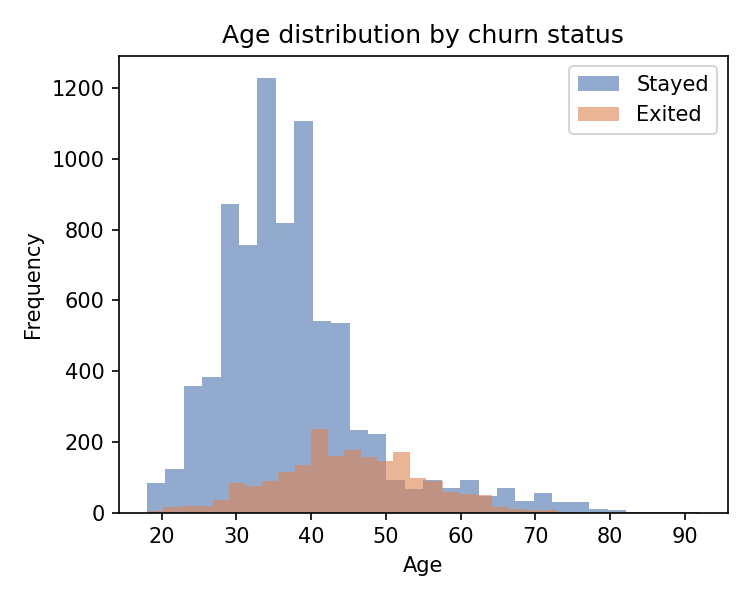

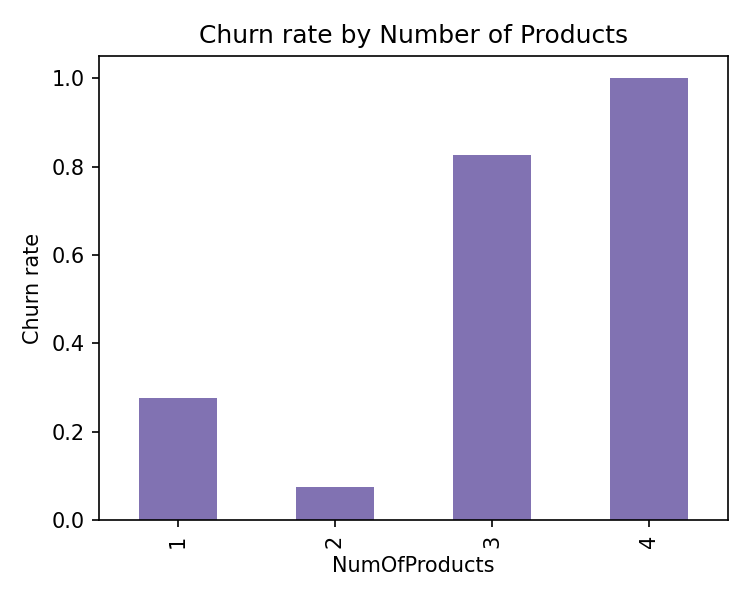

In [5]:
# Show how churn relates to Age and to the number of products a customer holds
display(Image(filename="../reports/figures/age_by_churn.png"))
display(Image(filename="../reports/figures/churn_by_numproducts.png"))

**Observation:** Churned customers skew somewhat older. Customers with 3-4
products churn far more than customers with 1-2 -- worth flagging for the
business, though the small sample sizes in the 3-4 product bins mean this
pattern should be treated as directional, not precise.

## Leakage analysis

| Column | Keep as model input? | Reason |
|---|---|---|
| RowNumber | No | Row index, not a customer attribute |
| CustomerId | No | Unique identifier, no predictive meaning, would let the model memorize instead of generalize |
| Surname | No | Unique identifier (also a fairness risk if used) |
| CreditScore, Geography, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary | Yes | Snapshot account attributes available at prediction time |
| Exited | N/A | Target only, never a feature |

No column in this dataset encodes information from *after* the point the
bank would actually want a churn prediction (there is no future-period
balance, no "months until close", etc.), so beyond dropping identifiers
there is no additional temporal-leakage risk to guard against here.

## Issue log
See `reports/eda_issue_log.md` for the full text version of the findings above (generated by this same audit).